# W12

In [18]:
import numpy as np
import matplotlib as plt
from matplotlib import pyplot as plt
import dynesty
from corner import corner

In [19]:
data = np.load('/Users/lorenzaimpicicche/Desktop/astrostatistics_bicocca_2025/solutions/transient.npy')
t, flux, err = data[:, 0], data[:, 1], data[:, 2]

Modello del burst

In [20]:
def loglike_burst(theta, t, y, yerr):
    b, A, t0, ln_alpha = theta
    model = np.piecewise(t, [t < t0, t >= t0], [b, lambda t: b + A * np.exp(-np.exp(ln_alpha) * (t - t0))])
    return -0.5 * np.sum(((y - model) / yerr) ** 2)

#Trasformazione dei parametri
def ptform_burst(u):
    b = 50 * u[0]  # b in [0, 50]
    A = 50 * u[1]  # A in [0, 50]
    t0 = 100 * u[2]  # t0 in [0, 100]
    ln_alpha = 5 * u[3] - 5  # ln_alpha in [-5, 5]
    return [b, A, t0, ln_alpha]

In [21]:
sampler_burst = dynesty.NestedSampler(loglike_burst, ptform_burst, ndim=4, nlive=500, logl_args=(t, flux, err))
sampler_burst.run_nested()
results_burst = sampler_burst.results

3807it [00:07, 270.74it/s, bound: 71 | nc: 9 | ncall: 70857 | eff(%):  5.373 | loglstar:   -inf < -87.119 <    inf | logz: -95.963 +/-  0.126 | dlogz: 37.747 >  0.509] /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very 

Modello gaussiana

In [22]:
def loglike_gaussian(theta, t, y, yerr):
    b, A, t0, sigma_W = theta
    model = b + A * np.exp(-((t - t0) ** 2) / (2 * sigma_W ** 2))
    return -0.5 * np.sum(((y - model) / yerr) ** 2)

def ptform_gaussian(u):
    b = 50 * u[0]  # b in [0, 50]
    A = 50 * u[1]  # A in [0, 50]
    t0 = 100 * u[2]  # t0 in [0, 100]
    sigma_W = 10 * u[3]  # sigma_W in [0, 10]
    return [b, A, t0, sigma_W]

In [23]:
sampler_gaussian = dynesty.NestedSampler(loglike_gaussian, ptform_gaussian, ndim=4, nlive=500, logl_args=(t, flux, err))
sampler_gaussian.run_nested()
results_gaussian = sampler_gaussian.results

4083it [00:03, 603.57it/s, bound: 30 | nc: 156 | ncall: 40650 | eff(%): 10.044 | loglstar:   -inf < -85.736 <    inf | logz: -95.561 +/-  0.128 | dlogz: 32.299 >  0.509]/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very

Evidenza Bayesiana

In [24]:
evidence_burst = np.exp(results_burst.logz[-1])
evidence_gaussian = np.exp(results_gaussian.logz[-1])
print(evidence_burst)
print(evidence_gaussian)

6.215643489517244e-28
7.407929243856565e-30


In [25]:
bayes_factor = evidence_gaussian / evidence_burst

if bayes_factor > 1:
    print("Il modello Gaussiano è preferito.")
    print(f"Bayes factor: {bayes_factor}")
else:
    print("Il modello del burst è preferito.")
    print(f"Bayes factor: {1 / bayes_factor}")


Il modello del burst è preferito.
Bayes factor: 83.90527615624717


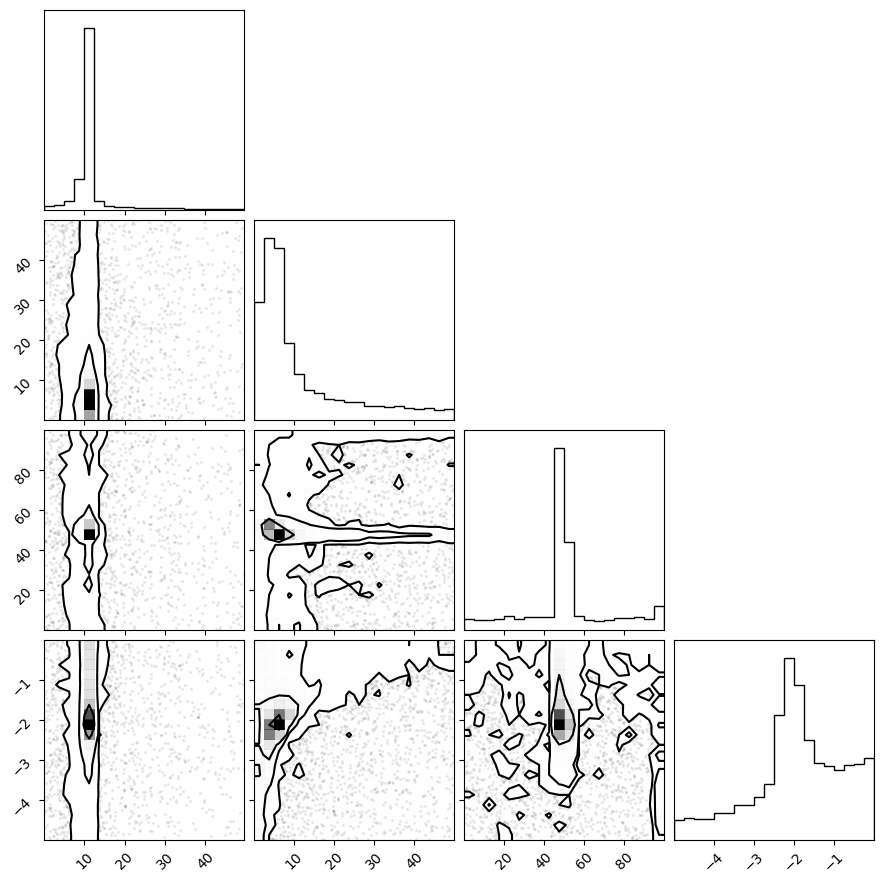

In [26]:
fig_burst = corner(results_burst.samples)

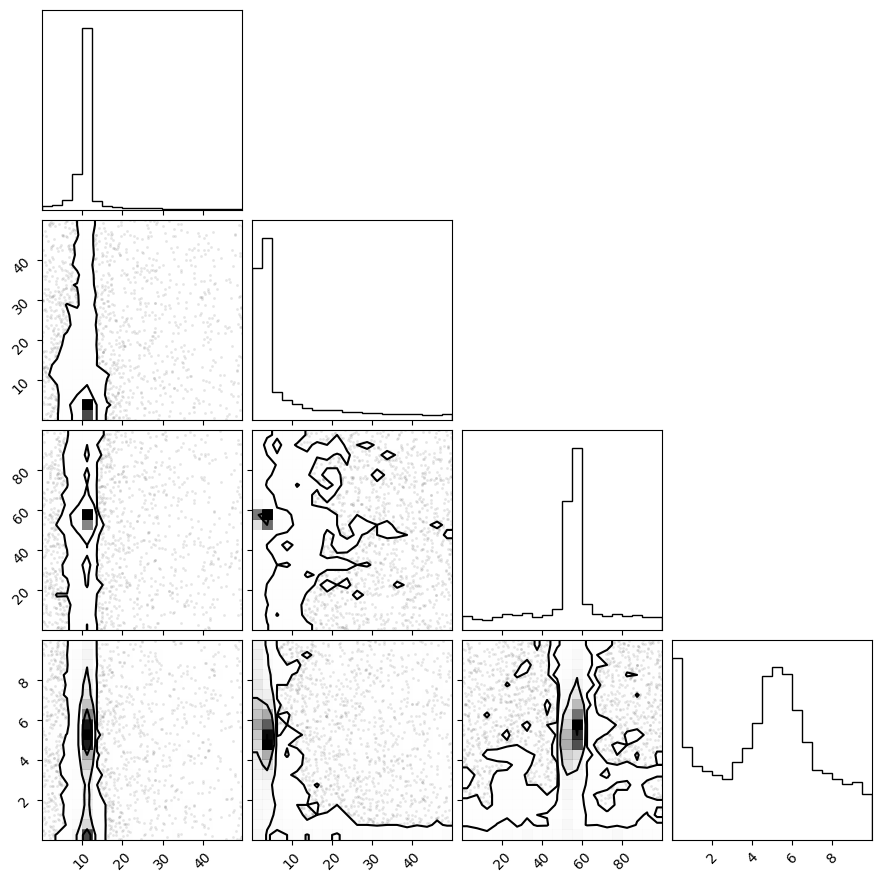

In [27]:
fig_gaussian = corner(results_gaussian.samples)